# A small DDM regression workflow

This notebook fits a diffusion decision model with two independent trial-level regressors. `x_drift` enters only the drift rate, and `x_boundary` enters only the boundary separation:

$$
v_t = h_v(\beta_{v,0} + \beta_{v,1} x_{v,t}), \qquad
a_t = h_a(\beta_{a,0} + \beta_{a,1} x_{a,t}).
$$

The four regression coefficients are time-invariant inference targets. The trial-varying `v` and `a` values are derived by the formulas and linked into valid DDM parameter ranges immediately before simulation.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import superstats as sup

SEED = 2026
NUM_TRIALS = 100
rng = np.random.default_rng(SEED)

## Trial-level regressors

Both regressors are randomized independently within each simulated dataset. Using values $-0.5$ and $0.5$ centers the intercepts at the midpoint of each experimental manipulation.

In [4]:
def generate_context(batch_size, num_steps):
    return {
        "x_drift": rng.choice([-0.5, 0.5], size=(batch_size, num_steps)),
        "x_boundary": rng.choice([-0.5, 0.5], size=(batch_size, num_steps)),
    }

context_simulator = sup.ContextSimulator(generate_context)
design_context = ("x_drift", "x_boundary")

## Regression model

The coefficient priors live on the unconstrained predictor scale. Scaled-sigmoid links map drift to $(-3, 3)$ and boundary separation to $(0.6, 2.2)$. Non-decision time and starting-point bias are fixed here to keep the example small.

In [ ]:
formula = sup.Formula([
    "v = v_intercept + v_slope * x_drift",
    "a = a_intercept + a_slope * x_boundary",
])

prior = sup.JointPrior(
    v_intercept=sup.Prior("normal", loc=0.0, scale=1.0),
    v_slope=sup.transition.RandomWalk(sigma=sup.Prior("halfnormal", scale=0.1)),
    a_intercept=sup.transition.RandomWalk(sigma=sup.Prior("halfnormal", scale=0.1)),
    a_slope=sup.Prior("normal", loc=0.0, scale=1.0),
    tau=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.05)
    ),
    bias=0.5,
)

model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    formula=formula,
    context_simulator=context_simulator,
    design_context=design_context,
    simulator_context=(),
    latent_link_function={
        "v_slope": sup.LinkFunction("scaled_sigmoid", bounds=(-6.0, 6.0)),
        "tau": sup.LinkFunction("scaled_sigmoid", bounds=(0.0, 2.0))
    },
    formula_link_function={
        "a": sup.LinkFunction("scaled_sigmoid", bounds=(0.5, 4.0)),
    },
    missing=None,
    contamination=None,
)

In [16]:
print("Time-varying inference targets:", model.local_keys)
print("Time-invariant inference targets:", model.shared_keys)
print("Formula-derived parameters:", model.formula_keys)

Time-varying inference targets: ['v_slope', 'a_intercept', 'tau']
Time-invariant inference targets: ['v_intercept', 'a_slope']
Formula-derived parameters: ['v', 'a']


## Pre-inference checks

The coefficient plot checks the raw inference priors. The push-forward plot checks their consequences after formulas and links have been applied and the DDM has generated observations.

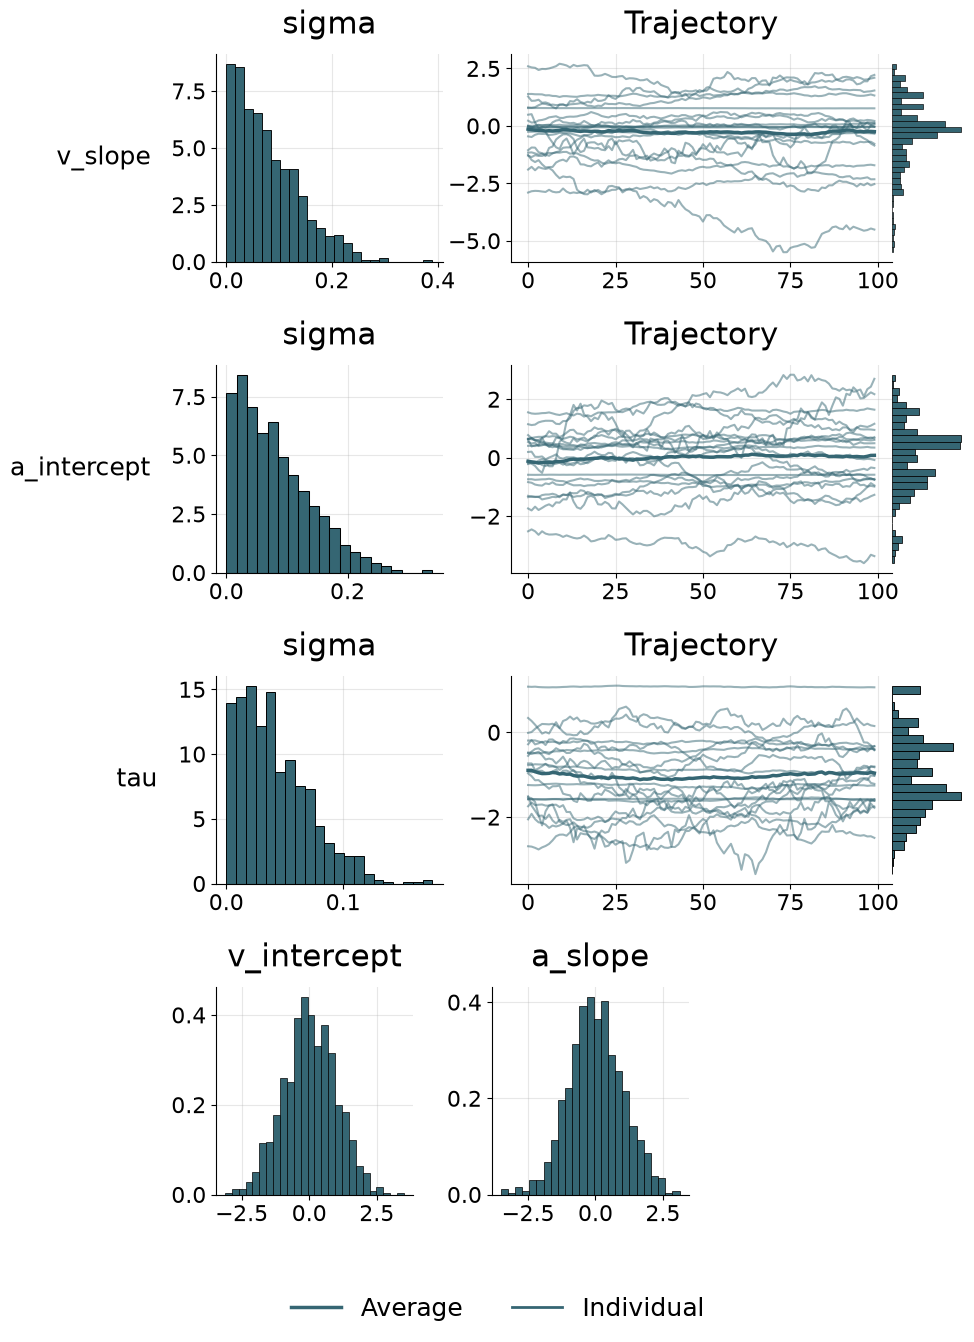

In [17]:
fig = model.plot_joint_prior(
    num_draws=1_000,
    num_steps=NUM_TRIALS,
)

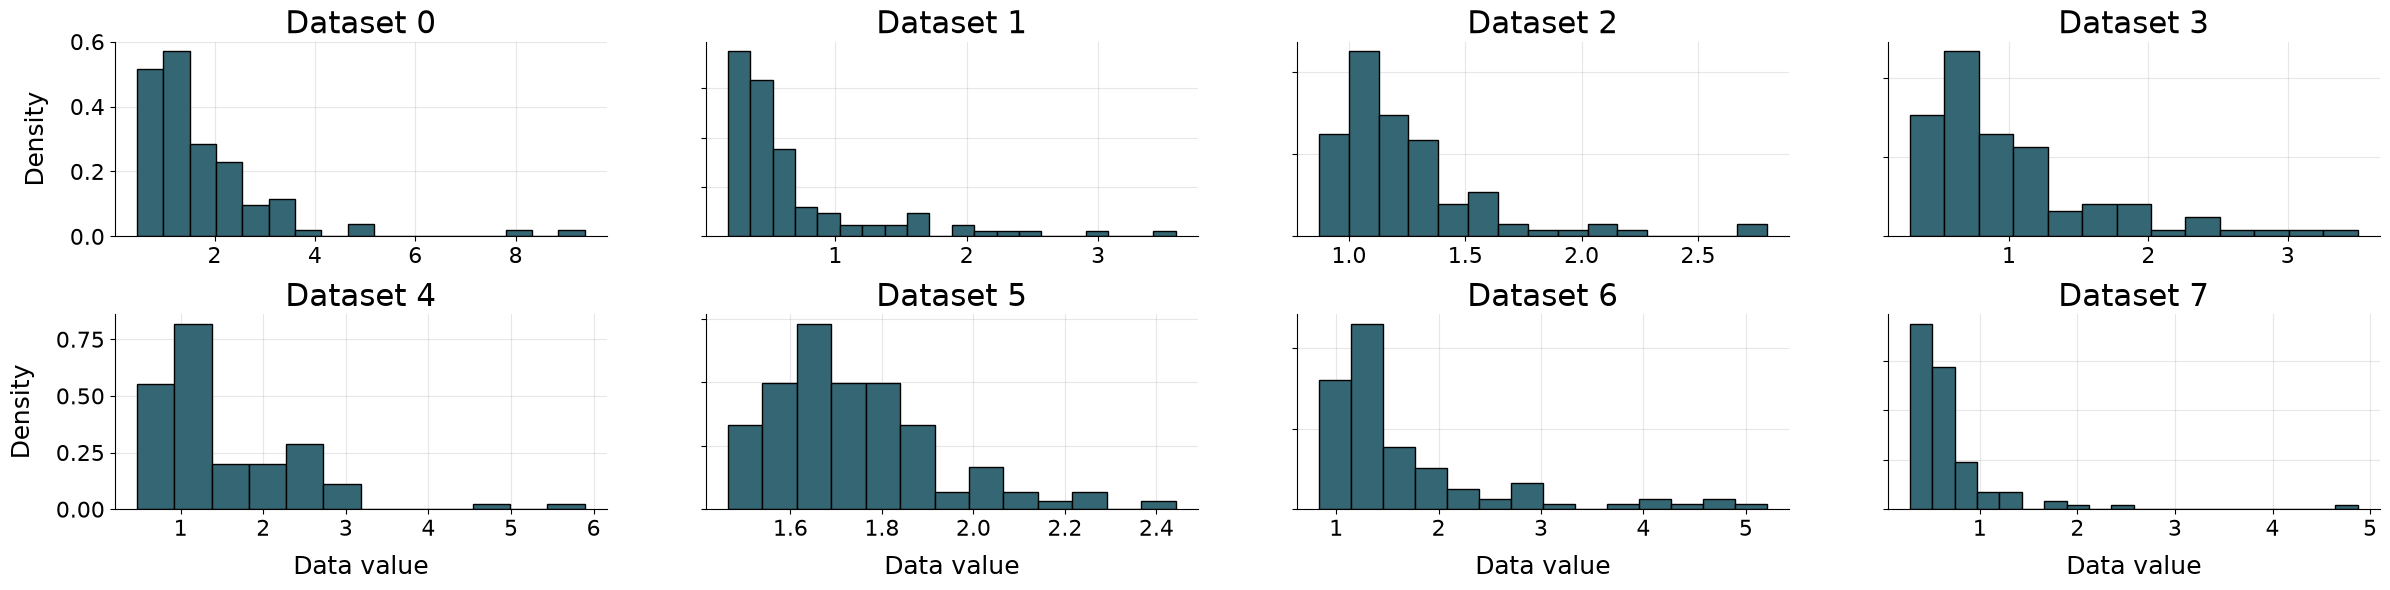

In [18]:
fig = model.plot_push_forward(
    batch_size=8,
    num_steps=NUM_TRIALS,
    data_dim="response_time",
    kind="dist",
    num_cols=4,
)

A single prior draw makes the two regression relationships explicit. `Model.sample()` returns the final linked formula parameters for inspection, but they are not additional inference targets.

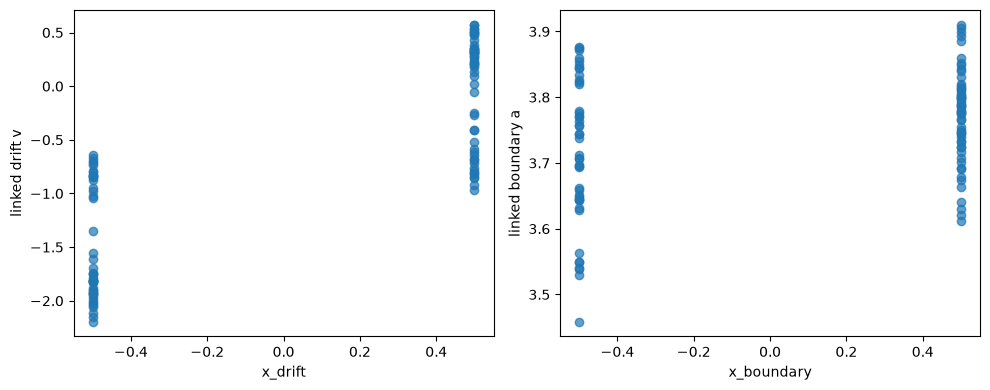

In [61]:
example = model.sample(batch_size=1, num_steps=NUM_TRIALS)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(example["x_drift"][0], example["v"][0, :, 0], alpha=0.7)
axes[0].set(xlabel="x_drift", ylabel="linked drift v")
axes[1].scatter(example["x_boundary"][0], example["a"][0, :, 0], alpha=0.7)
axes[1].set(xlabel="x_boundary", ylabel="linked boundary a")
fig.tight_layout()

## Amortized inference

All unknowns are time-invariant regression coefficients, so the workflow activates only its invariant posterior head. The recurrent encoder still sees the complete sequence of response times, choices, and both design variables.

In [63]:
workflow = sup.Workflow(
    model=model,
    approximator="marginal",
    mode="smoothing",
)

### Small offline training run

These settings keep the notebook suitable for experimentation. Increase the number of simulations and epochs for a substantive analysis.

In [64]:
train_data = model.sample(batch_size=25_000, num_steps=NUM_TRIALS)
validation_data = model.sample(batch_size=200, num_steps=NUM_TRIALS)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=validation_data,
    epochs=50,
    batch_size=32,
)

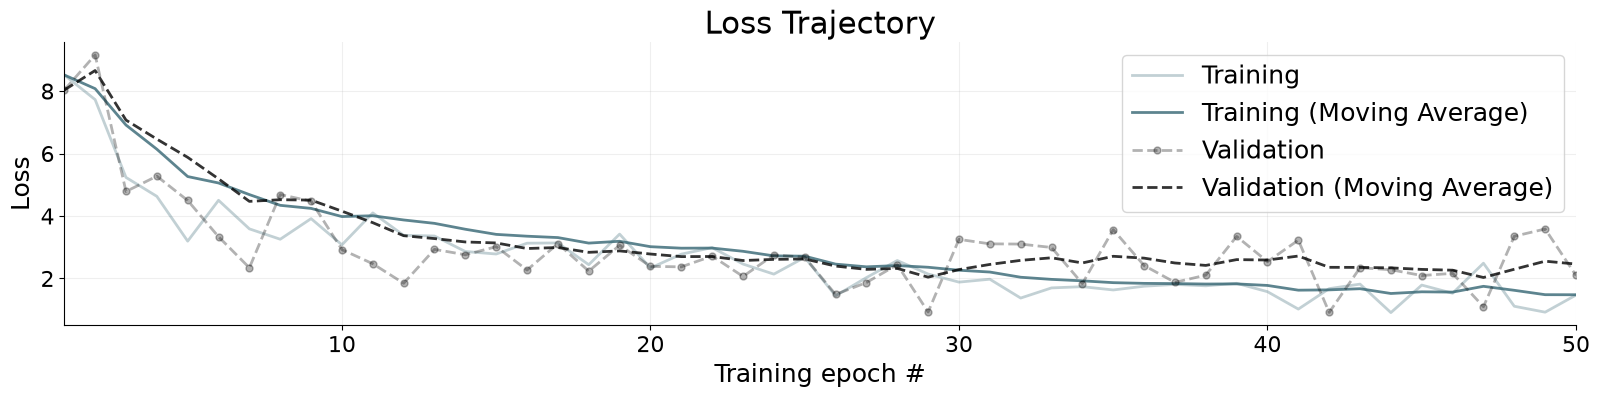

In [66]:
fig = workflow.plot_history(history)

## Held-out parameter recovery

Fresh simulations test whether the learned posterior recovers the four coefficients across their prior range. Recovery, calibration, and contraction should be interpreted together.

In [ ]:
targets = model.sample(batch_size=200, num_steps=NUM_TRIALS)
estimates = workflow.sample(
    data=targets,
    num_samples=500,
    batch_size=5,
)

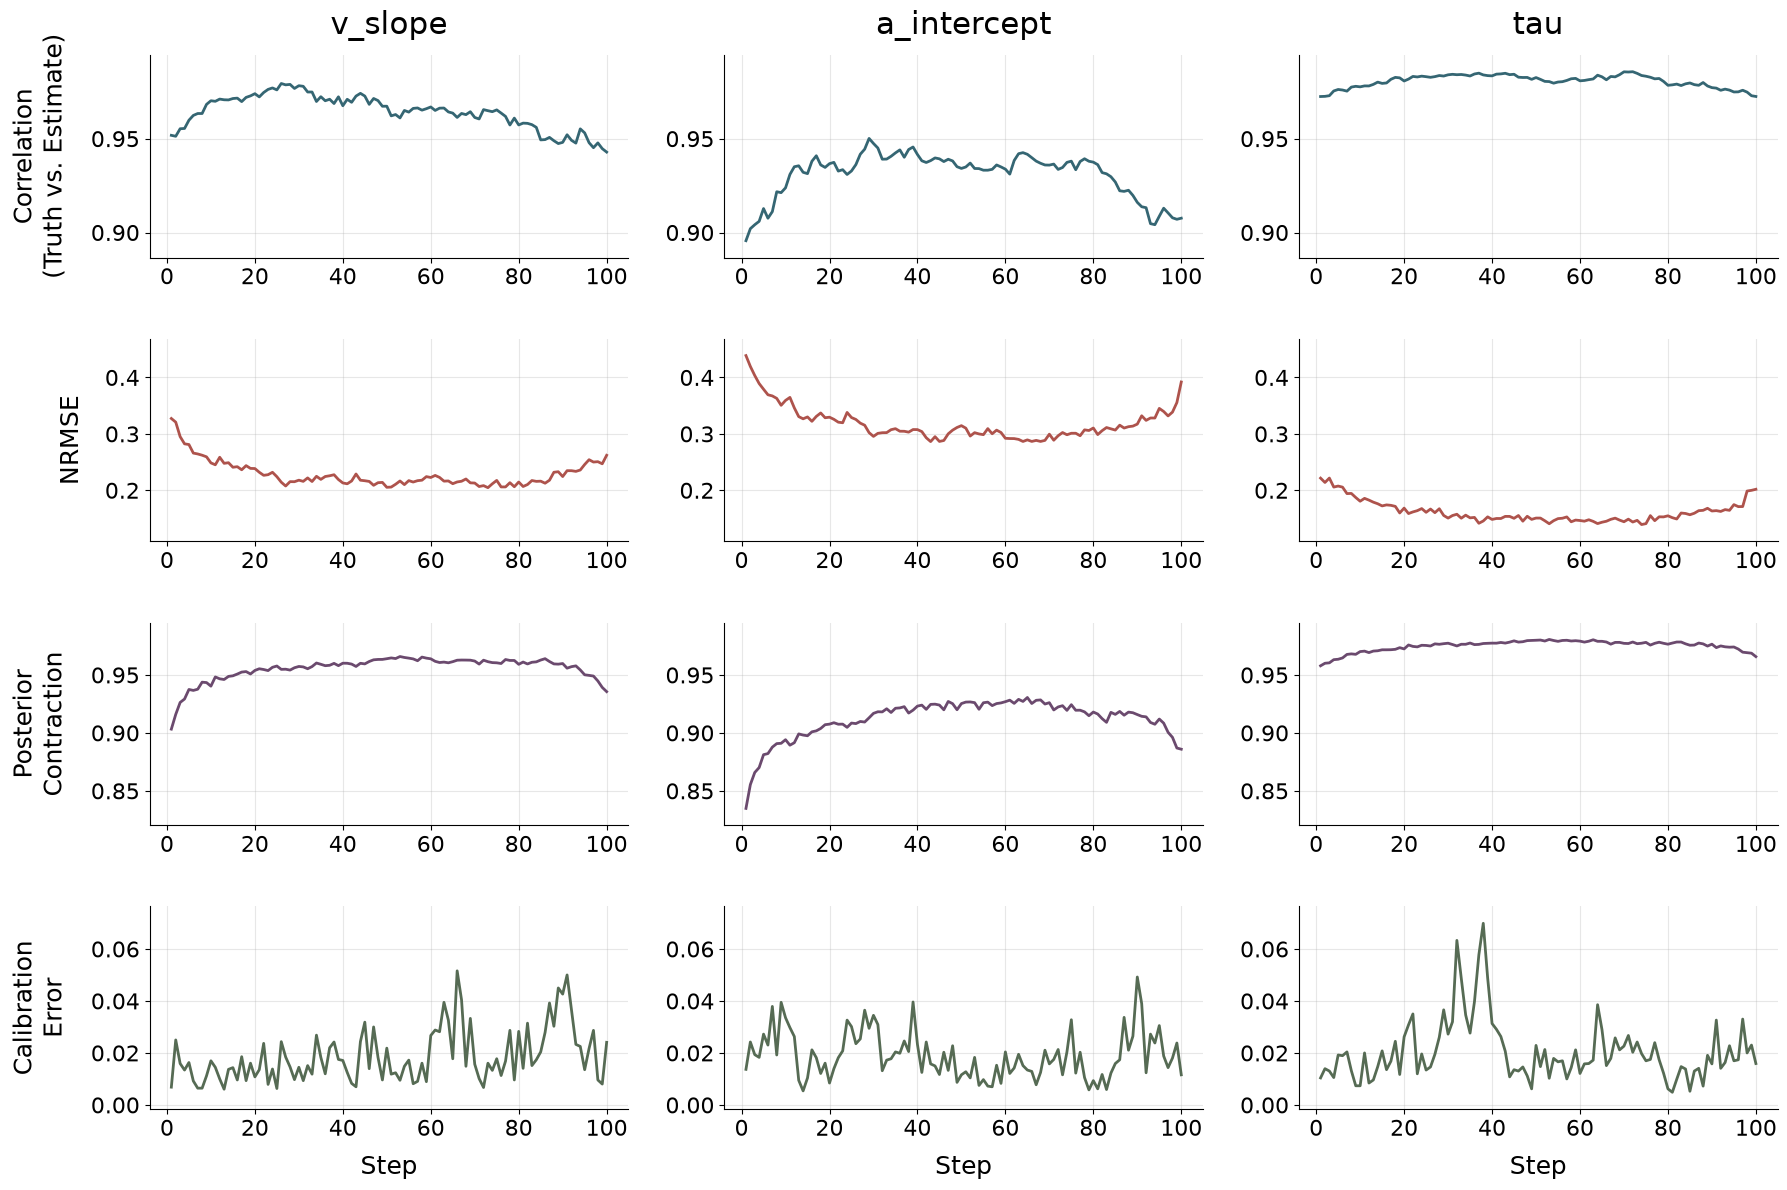

In [68]:
fig = workflow.verify_time_varying(targets=targets, estimates=estimates)

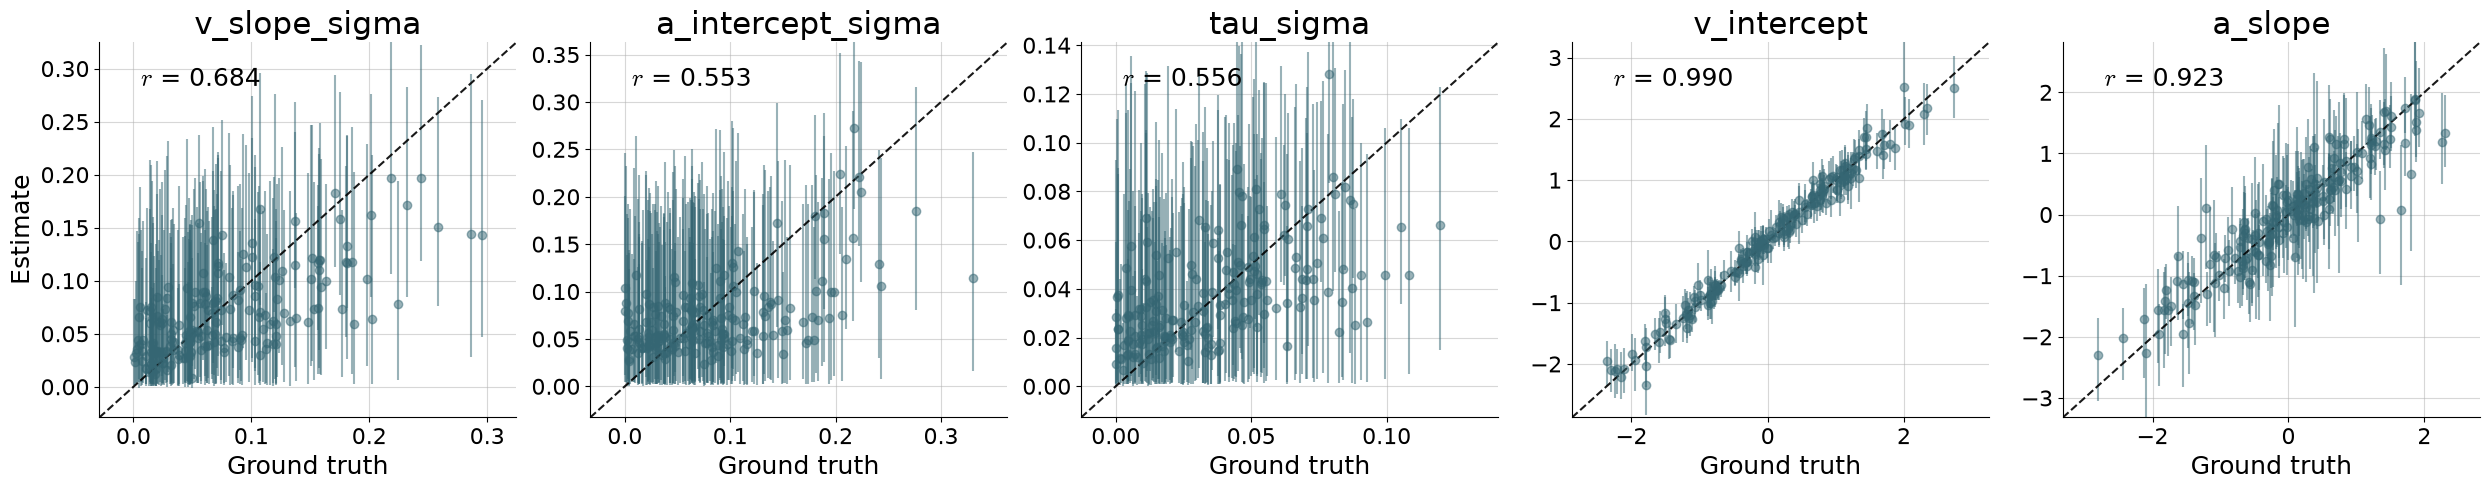

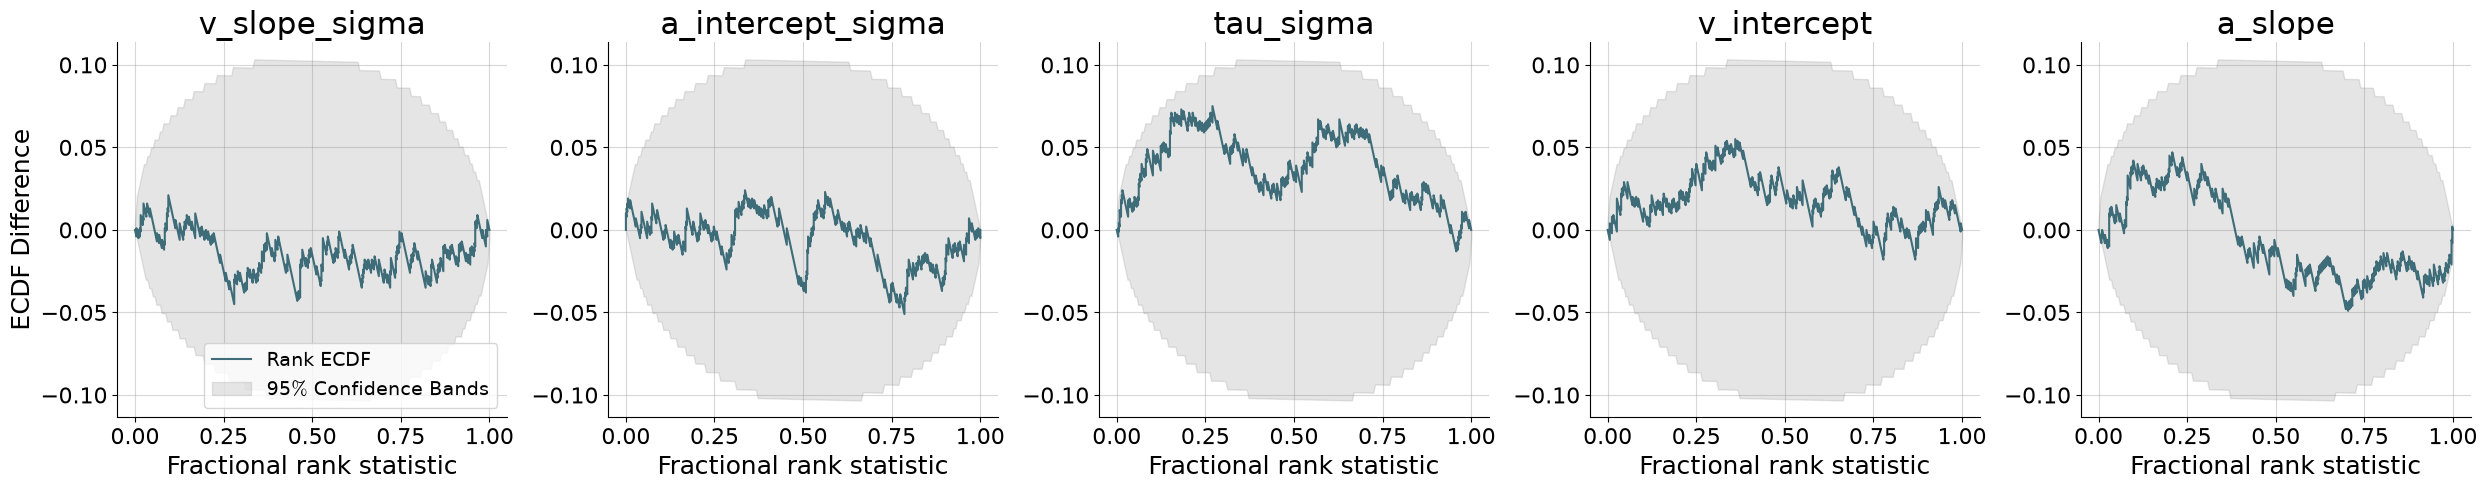

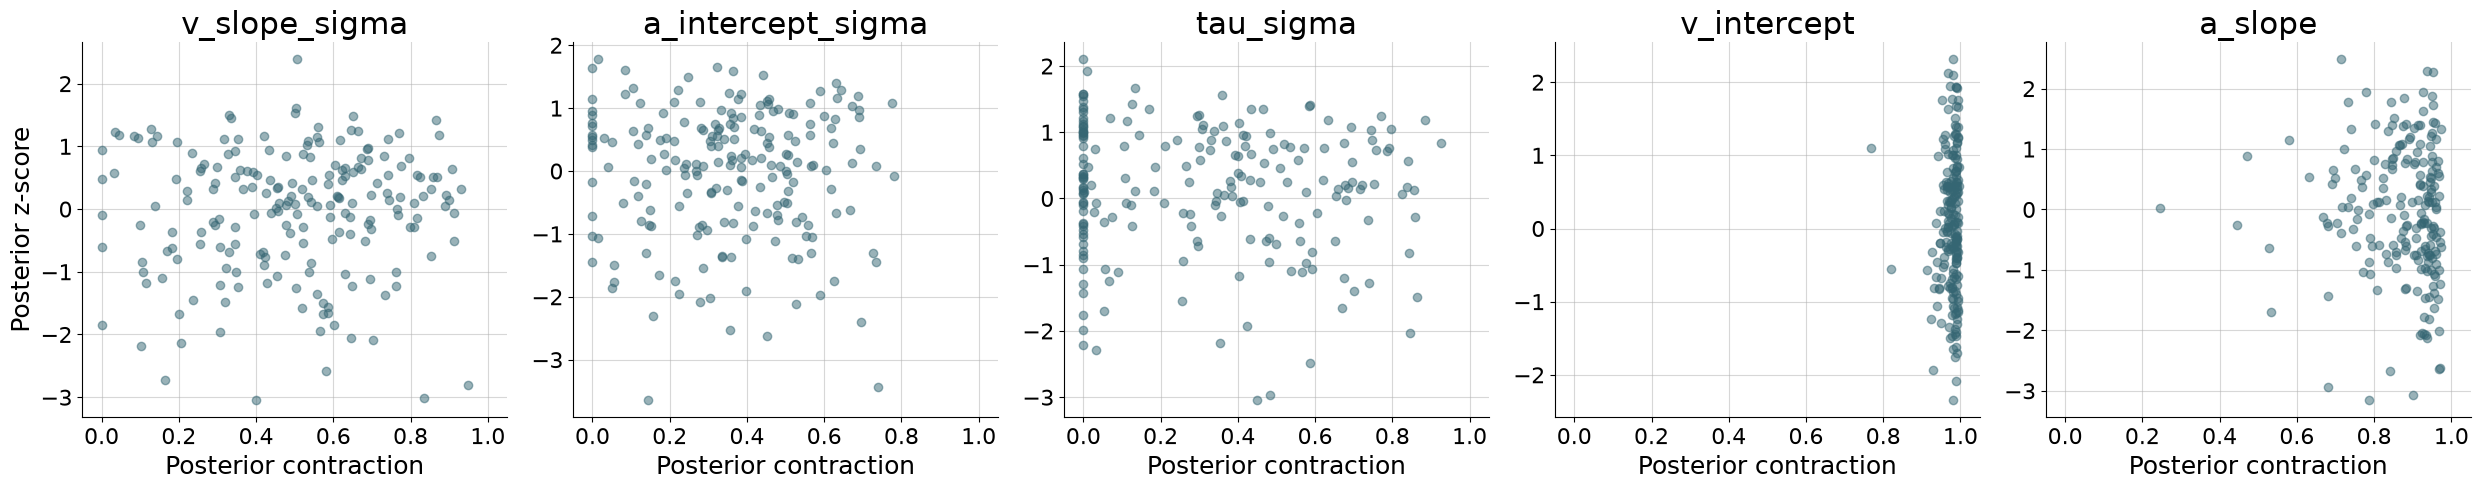

In [69]:
fig_recovery, fig_calibration, fig_contraction = workflow.verify_time_invariant(
    targets=targets,
    estimates=estimates,
)

## Fit one dataset

Here one additional simulation stands in for an empirical dataset. In a real application, use `workflow.prepare_data()` or construct a mapping with the same observation and context keys.

In [91]:
observed = model.sample(batch_size=1, num_steps=NUM_TRIALS)
posterior = workflow.sample(
    data=observed,
    num_samples=1_000,
    batch_size=1,
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

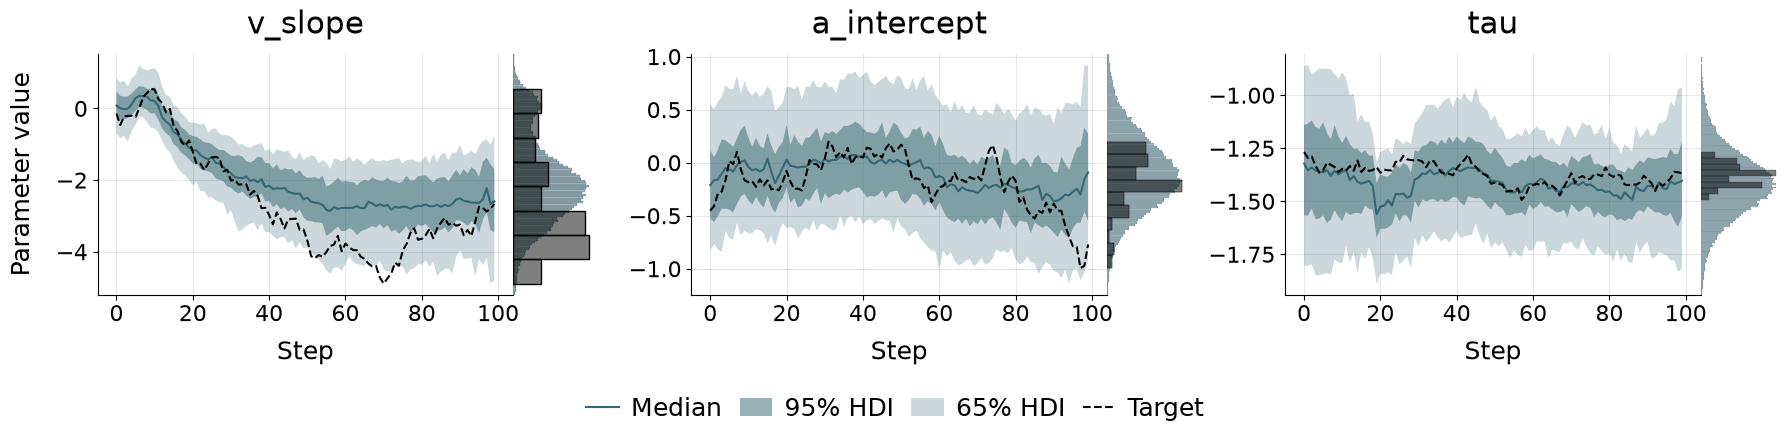

In [92]:
fig = workflow.plot_time_varying_posterior(
    estimates=posterior,
    targets=observed,
    data_idx=0,
)

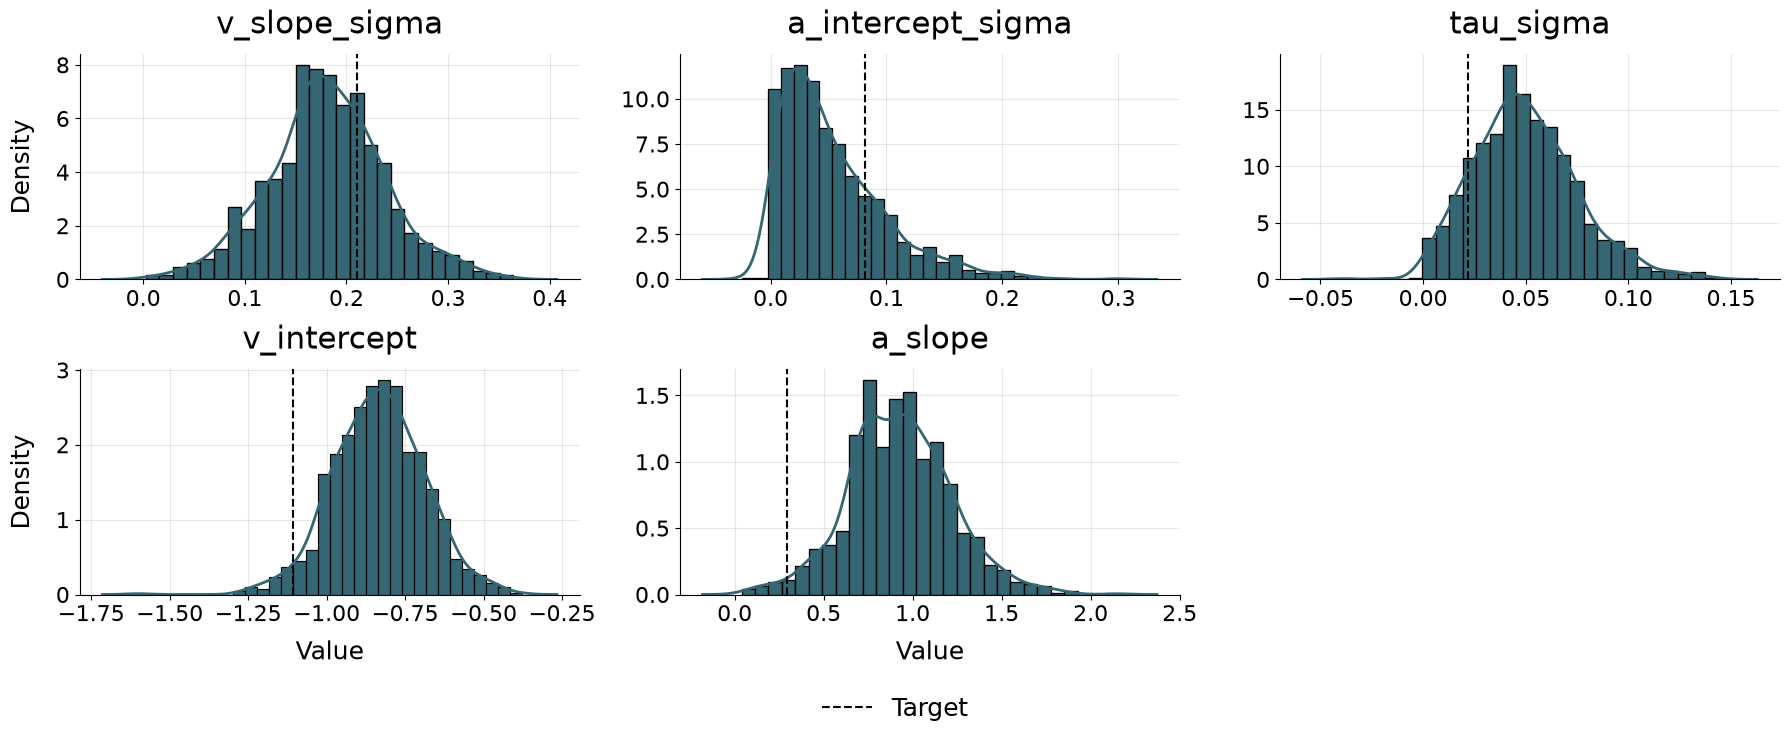

In [93]:
fig = workflow.plot_marginals(
    estimates=posterior,
    targets=observed,
    data_idx=0,
    dist_type="both",
)

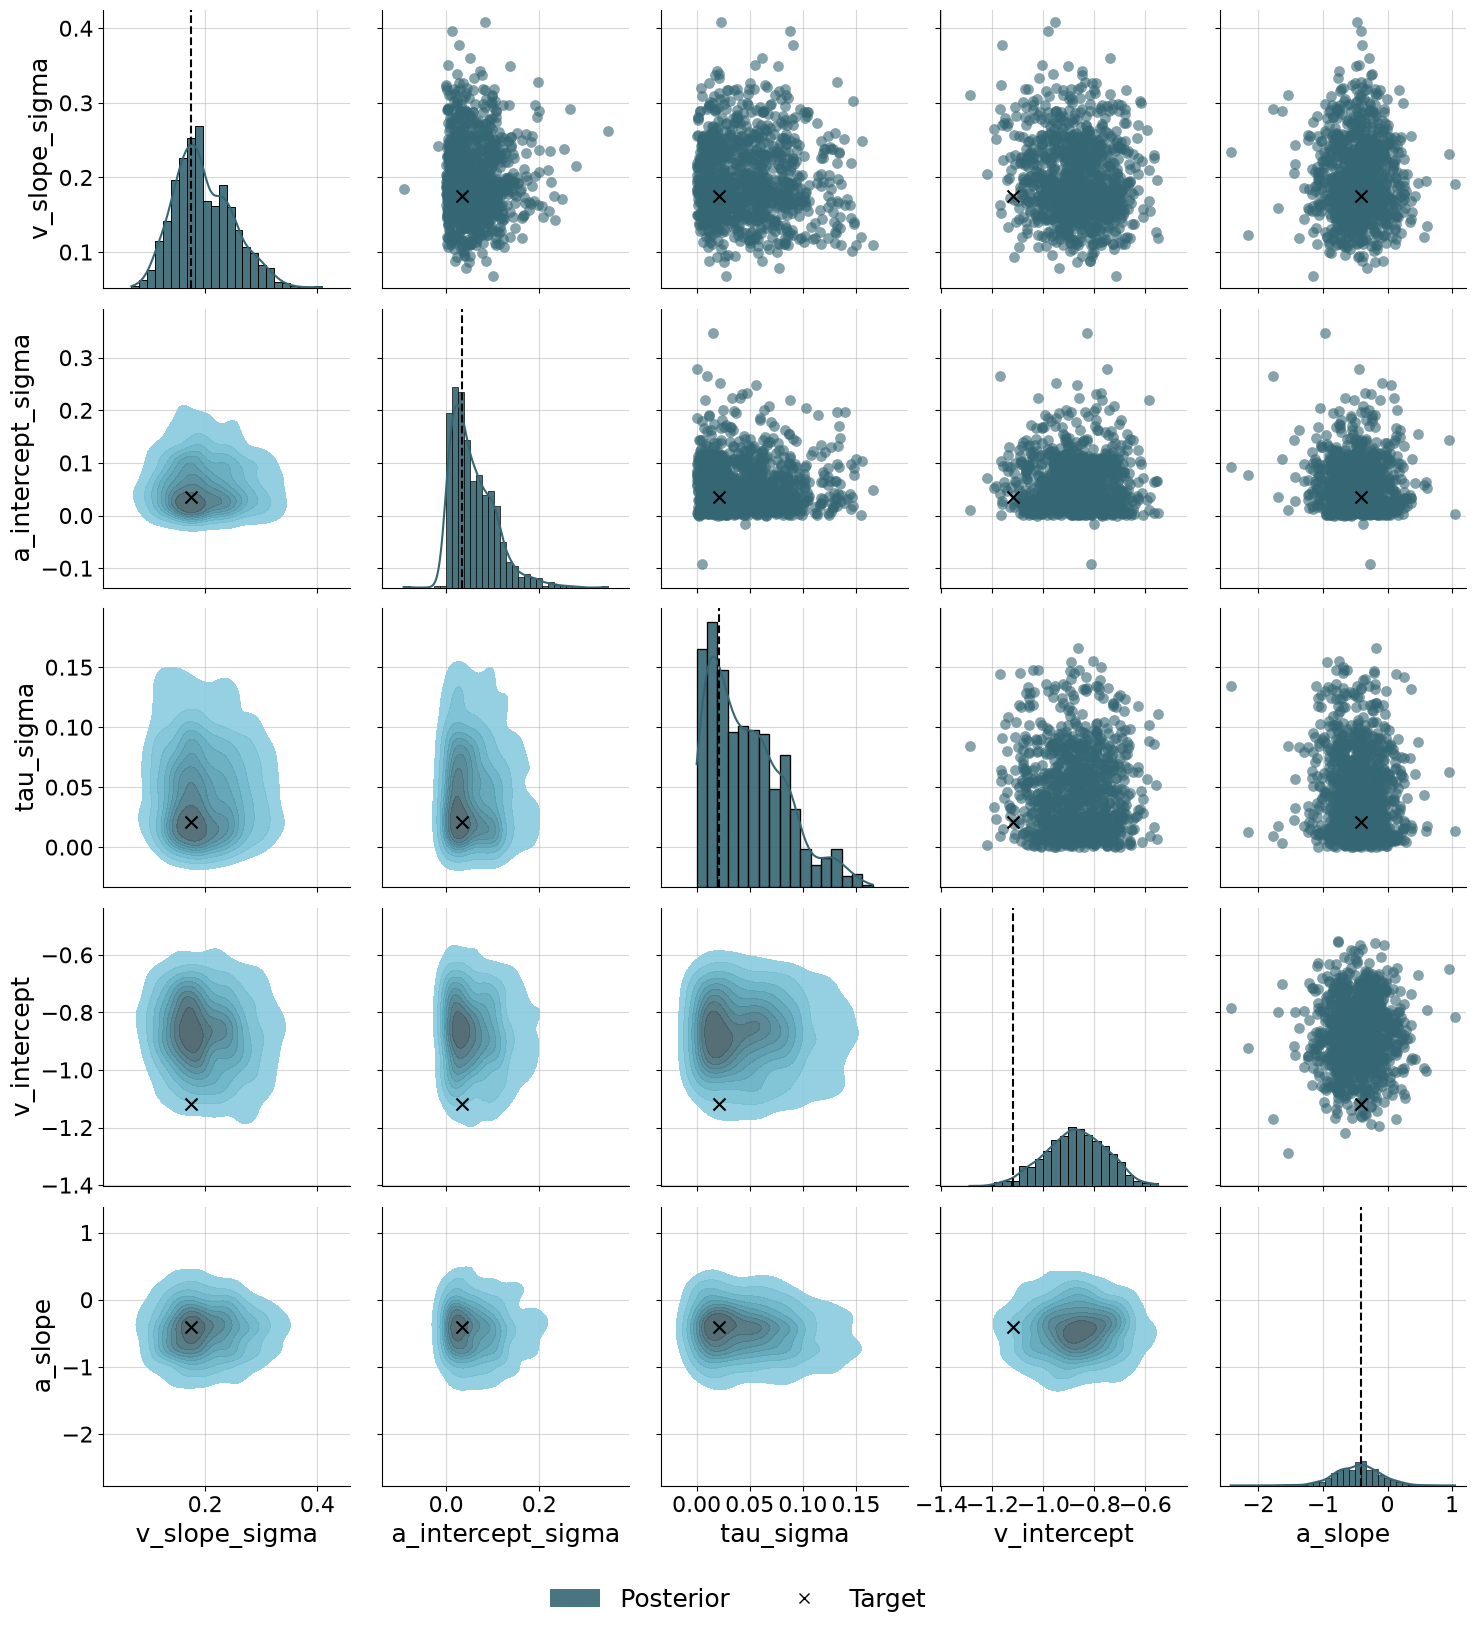

In [85]:
fig = workflow.plot_pairs(
    estimates=posterior,
    targets=observed,
    data_idx=0,
)

## Posterior predictive check

Resimulation uses the original regressors so each posterior predictive dataset has the same experimental design as the observed dataset.

In [86]:
observed_context = {key: observed[key] for key in design_context}
prediction = workflow.resimulate(
    estimates=posterior,
    num_sims=200,
    rng=SEED,
    context=observed_context,
)

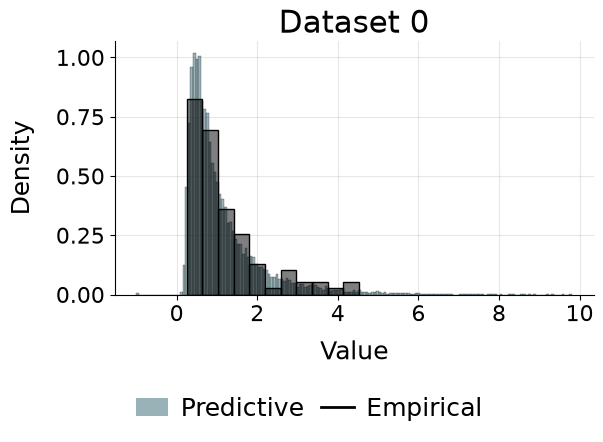

In [87]:
fig = sup.diagnostics.plot_posterior_resimulation(
    prediction=prediction,
    empirical=observed,
    data_dim="response_time",
    kind="dist",
    data_idx=0,
)

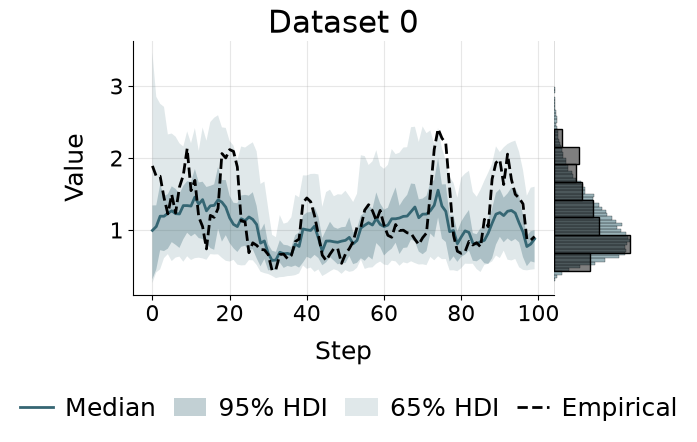

In [88]:
fig = sup.diagnostics.plot_posterior_resimulation(
    prediction=prediction,
    empirical=observed,
    data_dim="response_time",
    kind="time_series",
    smoothing="sma",
    smoothing_window=5,
    data_idx=0,
)

The complete analysis keeps three scales separate: coefficient priors are specified and inferred on the raw predictor scale, `Model` converts formula outputs to valid DDM parameters through the links, and posterior predictive checks evaluate the resulting model on the observation scale.